<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/Face_Expression_recognisation_model(transfer_learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013


Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

!unzip fer2013.zip -d /content/FER2013


Archive:  fer2013.zip
replace /content/FER2013/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
img_array = cv2.imread('/content/FER2013/test/angry/PrivateTest_10131363.jpg')

In [ ]:
img_array.shape #rgb

(48, 48, 3)

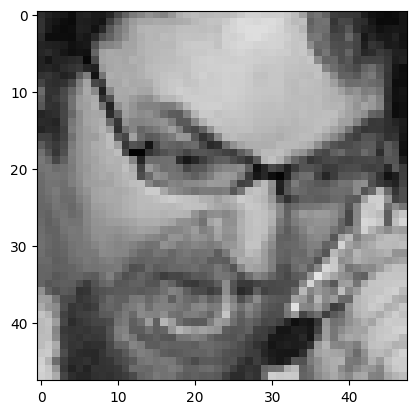

In [ ]:
plt.imshow(img_array)
plt.show()

In [ ]:
Datadirectory = '/content/FER2013/train' # training dataset
classes = ['0','1','2','3','4','5','6'] ## list of classes

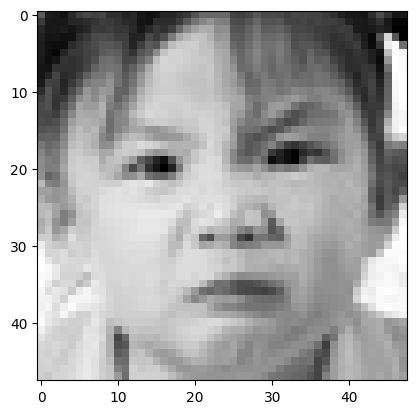

In [ ]:
for category in classes:
  path = os.path.join(Datadirectory,category)
  for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path,img))
    plt.imshow(cv2.cvtColor(img_array,cv2.COLOR_BGR2RGB))
    plt.show()
    break
  break

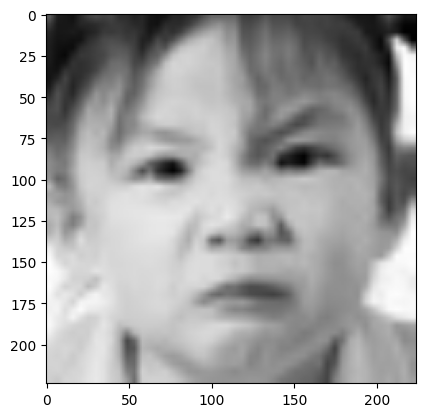

In [ ]:
img_size = 224  #vImageNet = 224*224
new_array = cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array,cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
new_array.shape

(224, 224, 3)

In [ ]:
# read all the images and convert in them to array
training_data = []
def create_training_data():
  for category in classes:
    path = os.path.join(Datadirectory,category)
    class_num = classes.index(category)
    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path,img))
        new_array = cv2.resize(img_array,(img_size,img_size))
        training_data.append([new_array,class_num])
      except Exception as e:
        pass


In [ ]:
create_training_data()

In [ ]:
print(len(training_data))

28709


In [ ]:
import random

random.shuffle(training_data)

In [ ]:
x = []
y = []

for features, label in training_data:
  x.append(features)
  y.append(label)

x = np.array(x).reshape(-1,img_size,img_size,3) # converting it to 4 dimension

In [ ]:
x.shape

(28709, 224, 224, 3)

In [ ]:
print(len(y))

28709


In [ ]:
# normalize the data

x = x/225.0

NameError: name 'x' is not defined

In [ ]:
y = np.array()


In [ ]:
from tensrflow import keras
from tensorflow.keras layers

In [ ]:
model = tf.keras.application.MobileNet()

In [ ]:
base_input = model.layers[0].input
base_output = model.layers[-2].output

final_output = layers.Dense(128)(bas_output) # adding new layer after the output of global poooling layer

final_output = layers.Activation('relu')(final_output)

final_output = layers.Dense(64)(final_output)

final_output = layers.Activation('relu')(final_output)
final_output = layers.Dense(7,activation='softmax')(final_output) # classification layer


In [ ]:
new_model = keras.model(inputs = base_input,outputs = final_output)
new_model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
new_model.fit(x,y,epochs = 25)


In [ ]:
new_model.save('my_model_64p35.h5')
new_model = tf.keras.models.load_model('my_model_64p35.h5' )

In [ ]:
frame = cv2.imread('happyboy.jpg')

In [ ]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [ ]:
gray = cv2.cvtcolor(frame,cv2.COLOR_BGR2GRAY)

In [ ]:
faces = faceCascade.detectMultiScale(gray,1.1,4)
for (x,y,w,h) in faces:
  roi_gray = gray[y:y+h,x:x+w]
  roi_color = frame[y:y+h,x:x+w]
  cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
  faces = faceCascade.detectMultiScale(roi_gray)
  if len(faces)==0:
    print('faces not detected')
  else:
    for(ex,ey,ew,eh) in faces:
      fac_roi = roi_color(ey: ey+eh,ex:ex+ew)

In [ ]:
final_image = cv2.resize(face_roi,(224,224))
final_image = np.expand_dims(final_image,axis  = 0)
final_image = final_image/225.0

**Real time video demo**


In [ ]:
path = 'haarcascade_frontalface_default.xml'
font_scale = 1.5
font = cv2.FONT_HERSHEY_PLAIN
